# What does a world university ranking actually reward?

**CWUR World University Rankings, 2018–19 — 1,000 institutions, 61 countries/territories.**

Rankings get read as if position 971 means something different from position 986.
This notebook takes the CWUR table apart to ask three questions about the
*ranking*, not about the universities in it:

1. **What is `Score` made of?** Can it be rebuilt from the seven indicator
   columns, and what does each one actually contribute?
2. **How much of the table is measured?** Several indicators are right-censored.
   Does that change the conclusions?
3. **How much precision does a rank position carry?**

### Findings

1. `World Rank` is nothing more than `Score` sorted descending — so correlating
   the two, which is where my first pass started, measures a definition.
2. `Score` is reproducible from the seven indicators at **R² = 0.98**. The
   research block accounts for **~60%** of its movement, the people block ~40%.
3. `Score` is published to one decimal place, giving **195 distinct values for
   1,000 institutions**. Sixteen universities all score 69.9 and are handed
   ranks 971–986. Below the top 200 the ordering is mostly tie-breaking.
4. Three country-level claims from my first pass were artefacts of tiny samples
   (Singapore n=2, Lebanon n=1) or of imputed values. They are corrected below.

### Data

| | |
|---|---|
| Source | Center for World University Rankings (CWUR), 2018–19 edition |
| File | `eighteen_nineteen_university_datasets.csv` — 1,000 × 12 |
| Encoding | Windows-1252 |
| Licence | *TODO: confirm CWUR's terms permit redistribution before publishing* |

Every indicator is a **rank**: lower is better, `1` is best in the world. That
inverts the direction of every correlation below.

| Column | Measures |
|---|---|
| `Quality of Education` | alumni winning major international awards |
| `Alumni Employment` | alumni in top executive positions |
| `Quality of Faculty` | faculty winning major international awards |
| `Research Output` | volume of research papers |
| `Quality Publications` | papers in top-tier journals |
| `Influence` | papers in highly-influential journals |
| `Citations` | highly-cited papers |

> *TODO: verify these descriptions against CWUR's published methodology and cite it.*


---
## 1. Setup

One split runs through this whole notebook: a **research** block (output,
publications, influence, citations) and a **people** block (education,
employment, faculty). The palette gives each a fixed colour — Okabe–Ito blue and
vermillion, the safest colourblind pair — and keeps it for every chart. The
diverging ramp is built from those same two hues so a correlation map reads in
the same language as everything else.


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import FuncFormatter
from PIL import Image

RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

DATA_PATH = Path("eighteen_nineteen_university_datasets.csv")
FIGURE_DIR = Path("figures")
FLAG_DIR = Path("assets/flags")

# ---------------------------------------------------------------- palette ----
# Semantic roles. A category keeps its colour for the whole notebook.
C = {
    "research": "#0072B2",   # Okabe-Ito blue       - research block
    "people":   "#D55E00",   # Okabe-Ito vermillion - education / employment / faculty
    "accent":   "#CC79A7",   # Okabe-Ito purple     - subject of a given chart
    "neutral":  "#6E6E6E",   # context, reference lines
    "grid":     "#E6E6E6",
    "text":     "#222222",
}

CONTINENT_COLORS = {
    "Europe":        "#0072B2",
    "North America": "#D55E00",
    "Asia":          "#009E73",
    "Oceania":       "#CC79A7",
    "South America": "#E69F00",
    "Africa":        "#56B4E9",
}

SEQ = LinearSegmentedColormap.from_list("seq", ["#FFFFFF", C["research"]])
DIV = LinearSegmentedColormap.from_list("div", [C["people"], "#FFFFFF", C["research"]])

# ------------------------------------------------------------ figure look ----
plt.rcParams.update({
    "figure.figsize":     (10, 6),
    "figure.dpi":         110,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
    "font.size":          11,
    "axes.titlesize":     14,
    "axes.titlelocation": "left",
    "axes.titlepad":      12,
    "axes.labelsize":     11,
    "axes.labelcolor":    C["text"],
    "axes.edgecolor":     C["neutral"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         C["grid"],
    "grid.linewidth":     0.8,
    "text.color":         C["text"],
    "xtick.color":        C["neutral"],
    "ytick.color":        C["neutral"],
    "legend.frameon":     False,
})

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)


---
## 2. Loading the data honestly

**Encoding.** The file is Windows-1252. Reading it as `unicode_escape` — the
workaround I used first — silently mangles 70 institution names: *University of
Wisconsin–Madison* loses its en dash, *University of São Paulo* its tilde. The
names were never corrupt, just decoded with the wrong codec. Headers also carry
non-breaking spaces (`Quality\xa0of Education`), which is why they resist
ordinary indexing.

**The sentinels are censoring, not missingness.** `-` and `> 1000` do not mean
"unknown" — they mean the true rank is *at least* as bad as a cutoff:

| Sentinel | Meaning | Reading |
|---|---|---|
| `> 1000` | ranked, but outside the top 1,000 | right-censored at 1000 |
| `-` | not ranked on this indicator at all | right-censored at the bottom of the observed range |

That distinction matters: filling them in is defensible, but any statistic built
on the filled values is a **bound**, not an estimate. So the loader returns three
aligned objects and every claim below says which one it used.


In [6]:
INDICATORS = [
    "Quality of Education",
    "Alumni Employment",
    "Quality of Faculty",
    "Research Output",
    "Quality Publications",
    "Influence",
    "Citations",
]

RESEARCH_BLOCK = ["Research Output", "Quality Publications", "Influence", "Citations"]
PEOPLE_BLOCK   = ["Quality of Education", "Alumni Employment", "Quality of Faculty"]

OUTSIDE_TOP_1000 = "> 1000"
NOT_RANKED = "-"


def load_cwur(path=DATA_PATH):
    """Read the CWUR table and separate measured ranks from censored ones.

    Returns
    -------
    observed : indicators as float, sentinels -> NaN
    ranked   : indicators as float, sentinels -> censoring floor
    censored : boolean, True where the value was a sentinel
    """
    raw = pd.read_csv(path, encoding="cp1252")
    raw.columns = [c.replace("\xa0", " ").strip() for c in raw.columns]

    censored = pd.DataFrame(
        {c: raw[c].astype(str).str.strip().isin([NOT_RANKED, OUTSIDE_TOP_1000])
         for c in INDICATORS},
        index=raw.index,
    )

    observed = raw.copy()
    for c in INDICATORS:
        observed[c] = pd.to_numeric(
            raw[c].replace({NOT_RANKED: np.nan, OUTSIDE_TOP_1000: np.nan}),
            errors="coerce",
        )

    # Censoring floor: one step past the worst rank actually visible.
    ranked = observed.copy()
    for c in INDICATORS:
        floor = (1001.0 if (raw[c].astype(str) == OUTSIDE_TOP_1000).any()
                 else observed[c].max() + 1)
        ranked[c] = observed[c].fillna(floor)

    return observed, ranked, censored


observed, ranked, censored = load_cwur()

print(f"{len(ranked):,} institutions across {ranked['Location'].nunique()} countries")
print(f"World Rank spans {ranked['World Rank'].min()}-{ranked['World Rank'].max()}")
ranked.head()


1,000 institutions across 61 countries
World Rank spans 1-1000


,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2.0,1.0,1.0,1.0,1.0,1.0,1.0,100.0
1,2,Stanford University,USA,2,10.0,3.0,2.0,10.0,4.0,3.0,2.0,96.7
2,3,Massachusetts Institute of Technology,USA,3,3.0,11.0,3.0,30.0,15.0,2.0,6.0,95.1
3,4,University of Cambridge,United Kingdom,1,5.0,19.0,6.0,12.0,8.0,6.0,19.0,94.0
4,5,University of Oxford,United Kingdom,2,9.0,25.0,10.0,9.0,5.0,7.0,4.0,93.2


### How much of this table is actually measured?


In [7]:
coverage = pd.DataFrame({
    "block": ["research" if c in RESEARCH_BLOCK else "people" for c in INDICATORS],
    "measured": (~censored[INDICATORS]).sum(),
    "censored": censored[INDICATORS].sum(),
    "censored %": (censored[INDICATORS].mean() * 100).round(1),
    "worst measured rank": observed[INDICATORS].max().astype("Int64"),
}).sort_values("censored %", ascending=False)

coverage


,block,measured,censored,censored %,worst measured rank
Quality of Faculty,people,269,731,73.1,303
Quality of Education,people,403,597,59.7,666
Alumni Employment,people,491,509,50.9,997
Influence,research,829,171,17.1,997
Citations,research,890,110,11.0,898
Research Output,research,923,77,7.7,1000
Quality Publications,research,949,51,5.1,997


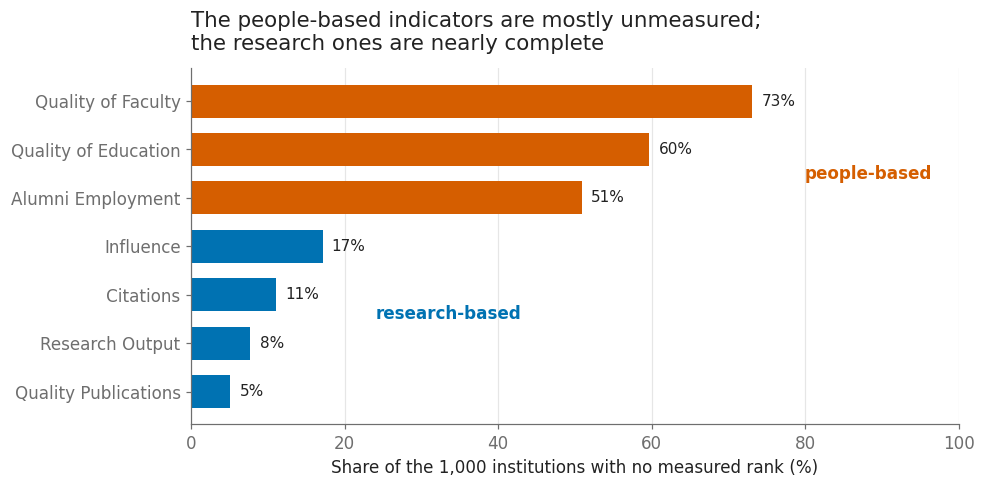

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2))

order = coverage.index[::-1]
bar_colors = [C["research"] if c in RESEARCH_BLOCK else C["people"] for c in order]

ax.barh(range(len(order)), coverage.loc[order, "censored %"], color=bar_colors, height=0.68)
for i, c in enumerate(order):
    ax.text(coverage.loc[c, "censored %"] + 1.2, i, f"{coverage.loc[c, 'censored %']:.0f}%",
            va="center", fontsize=10, color=C["text"])

ax.set_yticks(range(len(order)), order)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of the 1,000 institutions with no measured rank (%)")
ax.set_title("The people-based indicators are mostly unmeasured;\nthe research ones are nearly complete")
ax.grid(axis="y", visible=False)
ax.text(80, 4.4, "people-based", color=C["people"], fontsize=11, fontweight="bold")
ax.text(24, 1.5, "research-based", color=C["research"], fontsize=11, fontweight="bold")

FIGURE_DIR.mkdir(exist_ok=True)
plt.savefig(FIGURE_DIR / "01-coverage.png")
plt.show()


**Takeaway.** The two blocks are not equally measured. `Quality of Faculty` is
censored for 73% of institutions and `Quality of Education` for 60%, against
5–17% for the research indicators. The people-based measures count rare events
(major awards, top executive jobs) that most universities have none of, so those
institutions are *unrankable* rather than badly ranked.

Consequence: anything built on `Quality of Faculty` describes the 27% of rows
with a real measurement plus a constant standing in for the rest. The sections
below report those quantities both ways.


---
## 3. What is `Score` made of?

My first pass correlated every indicator against `World Rank` and read the result
as a finding. Before repeating that, it is worth checking what `World Rank`
actually is.


In [9]:
by_score = ranked.sort_values("Score", ascending=False).reset_index(drop=True)
is_identity = (by_score["World Rank"].to_numpy() == np.arange(1, len(ranked) + 1)).all()

print(f"World Rank == descending sort order of Score : {is_identity}")
print(f"Spearman(World Rank, Score)                  : "
      f"{ranked['World Rank'].corr(ranked['Score'], method='spearman'):.5f}")
print(f"Distinct Score values                        : "
      f"{ranked['Score'].nunique()} for {len(ranked):,} institutions")


World Rank == descending sort order of Score : True
Spearman(World Rank, Score)                  : -0.99995
Distinct Score values                        : 195 for 1,000 institutions


**`World Rank` is the sort order of `Score`.** Not correlated with it — *derived*
from it. The Spearman coefficient misses −1.0 only because tied scores get
distinct ranks. So "`Score` is the only variable negatively correlated with
`World Rank`" is arithmetic restating itself, not a result.

The real question is what drives `Score`. Since every indicator is a rank, I fit
`Score` on **log(rank)** — a move from 3rd to 4th matters far more than 300th to
301st — using only rows where nothing is censored, and bootstrap the rows to see
which coefficients are stable.


In [10]:
from numpy.linalg import lstsq

TOP_N = 200
BOOT_REPS = 2000


def recover_weights(frame, indicators=INDICATORS, reps=BOOT_REPS, seed=RANDOM_SEED):
    """Standardised OLS of Score on log(rank), bootstrapped over rows.

    Coefficients are standardised and rescaled to sum to 100%, so each reads as
    'share of the movement in Score this indicator accounts for'.
    """
    X = np.log(frame[indicators].to_numpy(float))
    y = frame["Score"].to_numpy(float)

    def _fit(Xi, yi):
        Xs = (Xi - Xi.mean(0)) / Xi.std(0)
        design = np.c_[Xs, np.ones(len(Xs))]
        beta, *_ = lstsq(design, yi, rcond=None)
        share = np.abs(beta[:-1])
        return share / share.sum(), design @ beta

    point, pred = _fit(X, y)
    r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()

    boot_rng = np.random.default_rng(seed)
    boots = np.array([
        _fit(X[idx], y[idx])[0]
        for idx in (boot_rng.integers(0, len(X), len(X)) for _ in range(reps))
    ])

    table = pd.DataFrame({
        "share %": point * 100,
        "lo": np.percentile(boots, 2.5, axis=0) * 100,
        "hi": np.percentile(boots, 97.5, axis=0) * 100,
        "block": ["research" if c in RESEARCH_BLOCK else "people" for c in indicators],
    }, index=indicators)

    return table.sort_values("share %", ascending=False), r2, boots


complete = observed.head(TOP_N).dropna(subset=INDICATORS)
weights, r2, boots = recover_weights(complete)

print(f"Fitted on {len(complete)} of the top {TOP_N} institutions with no censored indicator.")
print(f"R-squared = {r2:.3f}")
weights.round(1)


Fitted on 137 of the top 200 institutions with no censored indicator.
R-squared = 0.977


,share %,lo,hi,block
Influence,31.5,21.8,38.9,research
Quality of Faculty,23.9,16.4,29.9,people
Research Output,14.7,6.0,19.7,research
Citations,9.8,2.6,16.5,research
Alumni Employment,9.7,5.8,13.0,people
Quality of Education,8.0,3.2,11.9,people
Quality Publications,2.4,0.2,16.4,research


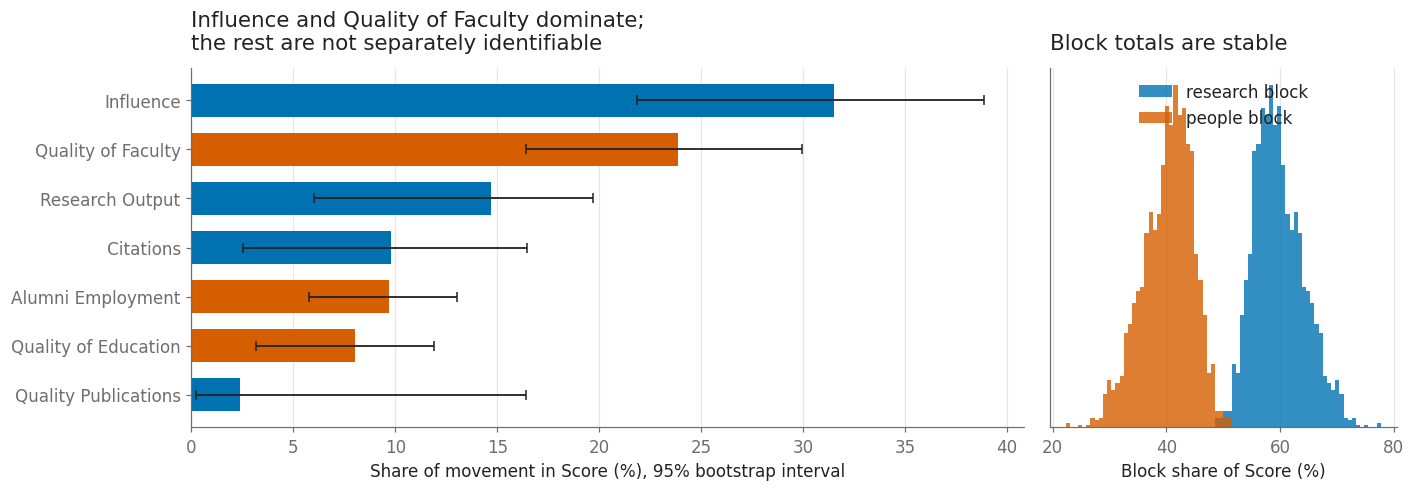

research  block: 59.8%  95% CI [52.3, 69.3]
people    block: 40.2%  95% CI [30.7, 47.7]


In [11]:
res_idx = [INDICATORS.index(c) for c in RESEARCH_BLOCK]
peo_idx = [INDICATORS.index(c) for c in PEOPLE_BLOCK]
block_shares = {
    "research": boots[:, res_idx].sum(axis=1) * 100,
    "people":   boots[:, peo_idx].sum(axis=1) * 100,
}

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [2.4, 1]})

order = weights.index[::-1]
ypos = np.arange(len(order))
cols = [C[weights.loc[c, "block"]] for c in order]

ax.barh(ypos, weights.loc[order, "share %"], color=cols, height=0.66)
ax.errorbar(weights.loc[order, "share %"], ypos,
            xerr=[weights.loc[order, "share %"] - weights.loc[order, "lo"],
                  weights.loc[order, "hi"] - weights.loc[order, "share %"]],
            fmt="none", ecolor=C["text"], elinewidth=1.2, capsize=3)
ax.set_yticks(ypos, order)
ax.set_xlabel("Share of movement in Score (%), 95% bootstrap interval")
ax.set_title("Influence and Quality of Faculty dominate;\nthe rest are not separately identifiable")
ax.grid(axis="y", visible=False)

for name, vals in block_shares.items():
    ax2.hist(vals, bins=40, color=C[name], alpha=0.8, label=f"{name} block")
ax2.set_xlabel("Block share of Score (%)")
ax2.set_yticks([])
ax2.set_title("Block totals are stable")
ax2.grid(axis="y", visible=False)
ax2.legend(loc="upper center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02-recovered-weights.png")
plt.show()

for name, vals in block_shares.items():
    lo, hi = np.percentile(vals, [2.5, 97.5])
    print(f"{name:9s} block: {vals.mean():4.1f}%  95% CI [{lo:.1f}, {hi:.1f}]")


**Takeaway.** `Score` is reproducible from the seven indicators at **R² = 0.98** —
it is a formula, not a measurement. The **research block accounts for ~60%** of
its movement (95% CI 52–69%), the people block ~40%.

The individual research weights are *not* separately identifiable: those four
indicators correlate 0.78–0.96 with each other *within this fitting sample*, so the regression can shuffle
credit between them freely. That is why `Quality Publications` gets an interval
of roughly [0, 16] — wide enough to be meaningless on its own. The **block
totals** are the trustworthy quantity, and the histogram on the right shows they
are tight.

> *TODO: compare these recovered shares against CWUR's published weights for this
> edition and note where they disagree.*


---
## 4. How much precision does a rank position carry?

`Score` is published to one decimal place. With a range of 69.8–100 that allows
only ~300 possible values, and only 195 actually occur across 1,000 institutions.
Every tie still gets a distinct `World Rank`.


In [12]:
tie_size = ranked.groupby("Score")["World Rank"].transform("count")
bands = pd.cut(ranked["World Rank"], [0, 100, 200, 400, 600, 800, 1000])
tie_by_band = (ranked.assign(tie=tie_size, band=bands)
                     .groupby("band", observed=True)["tie"].mean())

biggest = (ranked.groupby("Score")["World Rank"]
                 .agg(["count", "min", "max"])
                 .sort_values("count", ascending=False))
print(biggest.head(3).to_string())
print()
worst_score = biggest.index[0]
print(f"{int(biggest.iloc[0]['count'])} institutions share Score {worst_score}, "
      f"holding World Ranks {int(biggest.iloc[0]['min'])}-{int(biggest.iloc[0]['max'])}.")


       count  min  max
Score                 
69.9      16  971  986
70.0      16  955  970
70.1      16  939  954

16 institutions share Score 69.9, holding World Ranks 971-986.


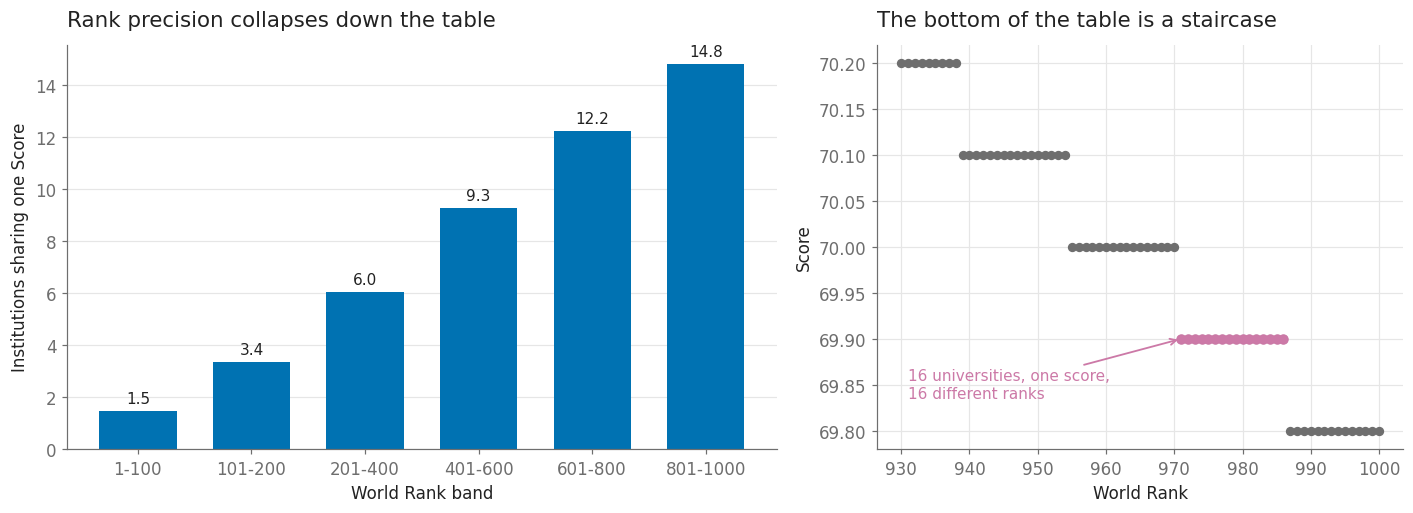

In [13]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})

ax.bar(range(len(tie_by_band)), tie_by_band.values, color=C["research"], width=0.68)
for i, v in enumerate(tie_by_band.values):
    ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=10)
ax.set_xticks(range(len(tie_by_band)),
              [f"{int(iv.left)+1}-{int(iv.right)}" for iv in tie_by_band.index], rotation=0)
ax.set_xlabel("World Rank band")
ax.set_ylabel("Institutions sharing one Score")
ax.set_title("Rank precision collapses down the table")
ax.grid(axis="x", visible=False)

zoom = ranked[ranked["World Rank"].between(930, 1000)]
ax2.scatter(zoom["World Rank"], zoom["Score"], s=26, color=C["neutral"], zorder=3)
flat = ranked[ranked["Score"] == worst_score]
ax2.scatter(flat["World Rank"], flat["Score"], s=34, color=C["accent"], zorder=4)
ax2.annotate(f"{len(flat)} universities, one score,\n{len(flat)} different ranks",
             xy=(flat["World Rank"].min(), worst_score),
             xytext=(931, worst_score - 0.05), fontsize=10, color=C["accent"],
             ha="left", va="center",
             arrowprops=dict(arrowstyle="->", color=C["accent"], linewidth=1.2))
ax2.set_xlabel("World Rank")
ax2.set_ylabel("Score")
ax2.set_title("The bottom of the table is a staircase")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03-rank-precision.png")
plt.show()


**Takeaway.** In the top 100, roughly 1.5 institutions share a score. In ranks
801–1000 it is **14.8**. Sixteen universities all score 69.9 and are handed ranks
971 through 986 — a 16-place spread with **zero** measured difference between them.

So a claim like "we rose 30 places this year" is, in the bottom half of this
table, compatible with no change in any underlying indicator. The precision of
the rank is a presentation artefact of rounding `Score` to one decimal.


---
## 5. Reading the correlations correctly

My first pass called the positive correlations "contradictory with the feature
names". They are not. Every indicator is a **rank**, and so is `World Rank` —
low is good for both — so a positive correlation is exactly what a well-behaved
indicator should produce. Spearman is the right coefficient here, not Pearson,
because these are ordinal.


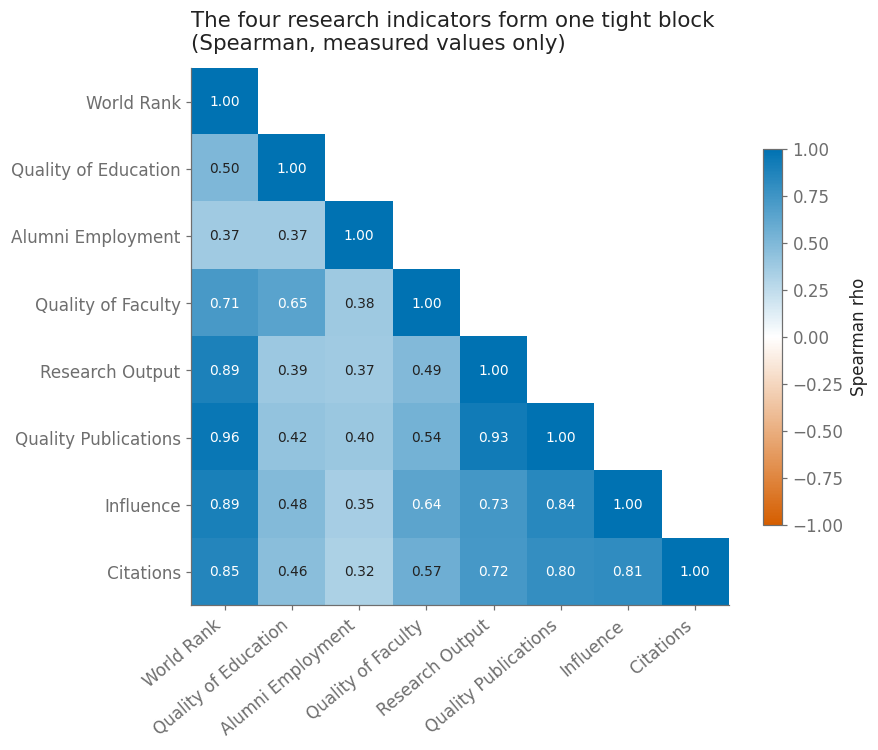

In [14]:
corr_cols = ["World Rank"] + INDICATORS
corr = observed[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.2, 6.8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
data = np.ma.masked_array(corr.values, mask)

im = ax.imshow(data, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=40, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(i + 1):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else C["text"])
ax.set_title("The four research indicators form one tight block\n(Spearman, measured values only)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman rho")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04-correlations.png")
plt.show()


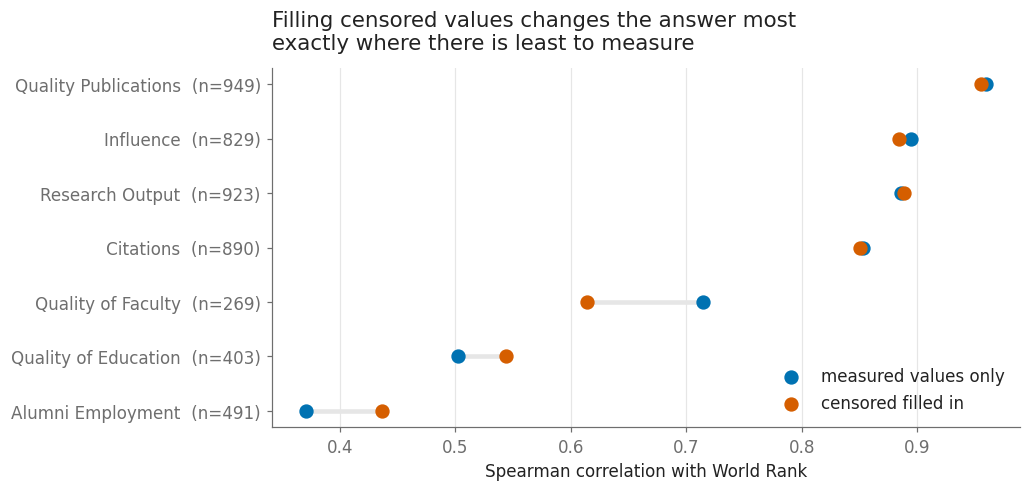

,measured only,n measured,with censored filled
indicator,,,
Alumni Employment,0.370,491,0.436
Quality of Education,0.502,403,0.544
Quality of Faculty,0.715,269,0.614
Citations,0.854,890,0.851
Research Output,0.886,923,0.888
Influence,0.895,829,0.885
Quality Publications,0.959,949,0.955


In [15]:
rows = []
for c in INDICATORS:
    pair = observed[[c, "World Rank"]].dropna()
    rows.append({
        "indicator": c,
        "measured only": pair[c].corr(pair["World Rank"], method="spearman"),
        "n measured": len(pair),
        "with censored filled": ranked[c].corr(ranked["World Rank"], method="spearman"),
    })
shift = pd.DataFrame(rows).set_index("indicator").sort_values("measured only")

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(shift))
ax.hlines(y, shift["measured only"], shift["with censored filled"],
          color=C["grid"], linewidth=3, zorder=1)
ax.scatter(shift["measured only"], y, s=70, color=C["research"], zorder=3, label="measured values only")
ax.scatter(shift["with censored filled"], y, s=70, color=C["people"], zorder=3, label="censored filled in")
ax.set_yticks(y, [f"{i}  (n={n})" for i, n in zip(shift.index, shift["n measured"])])
ax.set_xlabel("Spearman correlation with World Rank")
ax.set_title("Filling censored values changes the answer most\nexactly where there is least to measure")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

shift.round(3)


**Takeaway.** The four research indicators correlate 0.72–0.93 with *each other* —
they are close to one variable measured four ways, which is why section 3 could
not separate their weights.

The second chart is the reason to keep both versions of the data. For the
research indicators the two estimates are nearly identical. For `Quality of
Faculty` the correlation moves from **0.71 measured to 0.61 filled** — the fill
is doing real work, on the column where 73% of rows have nothing to measure. My
first pass reported only the filled number and did not mention it.


---
## 6. Where are these universities?

Two corrections to my first pass: Egypt was mapped to Asia, and `USA` needed
normalising. Russia is placed in Europe here — most of its ranked institutions
are west of the Urals — but it is a judgement call, so it is flagged rather than
buried.


In [16]:
CONTINENT_MAP = {
    **{c: "Europe" for c in [
        "United Kingdom", "Switzerland", "France", "Denmark", "Germany", "Sweden",
        "Italy", "Netherlands", "Norway", "Spain", "Finland", "Belgium", "Austria",
        "Czech Republic", "Portugal", "Ireland", "Poland", "Greece", "Serbia",
        "Slovenia", "Hungary", "Croatia", "Iceland", "Estonia", "Slovak Republic",
        "Lithuania", "Romania", "Bulgaria", "Russia"]},          # Russia: judgement call
    **{c: "North America" for c in ["USA", "Canada", "Mexico"]},
    **{c: "South America" for c in ["Brazil", "Argentina", "Chile", "Colombia", "Uruguay"]},
    **{c: "Asia" for c in [
        "Japan", "Israel", "South Korea", "China", "Singapore", "Taiwan", "Hong Kong",
        "Saudi Arabia", "Iran", "India", "Malaysia", "Thailand", "Turkey", "Cyprus",
        "Lebanon", "Pakistan", "Macau"]},
    **{c: "Africa" for c in ["South Africa", "Uganda", "Tunisia", "Nigeria", "Egypt"]},
    **{c: "Oceania" for c in ["Australia", "New Zealand"]},
}

for frame in (observed, ranked):
    frame["Continent"] = frame["Location"].map(CONTINENT_MAP)

unmapped = sorted(ranked.loc[ranked["Continent"].isna(), "Location"].unique())
assert not unmapped, f"unmapped countries: {unmapped}"
print("every country mapped to a continent")
ranked["Continent"].value_counts().rename("institutions").to_frame()


every country mapped to a continent


,institutions
Continent,
Europe,388
Asia,292
North America,245
South America,31
Oceania,30
Africa,14


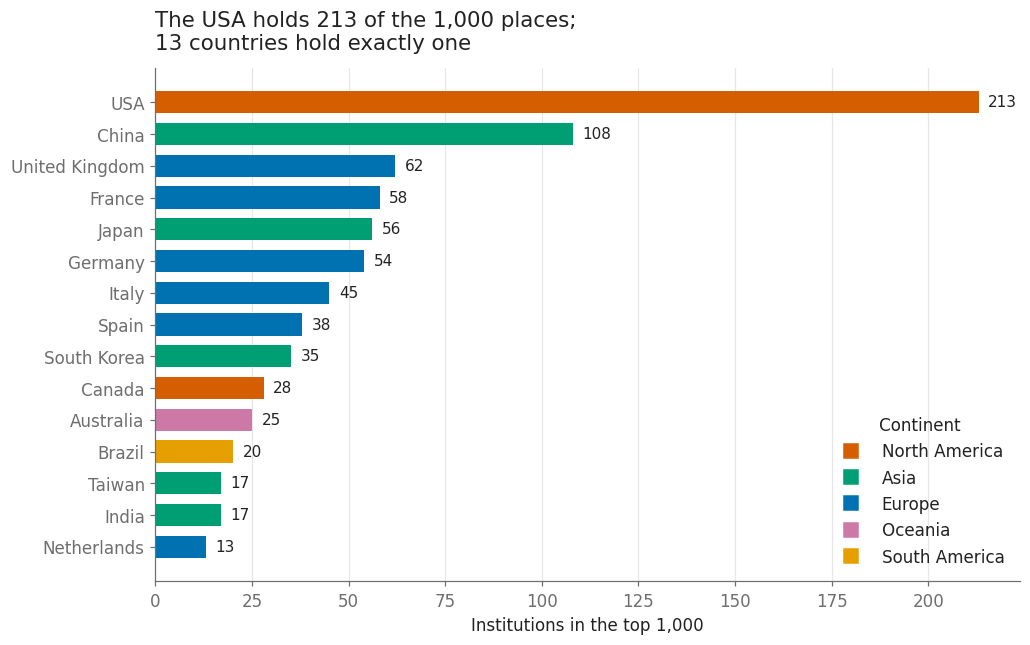

In [17]:
counts = ranked["Location"].value_counts()
TOP_K = 15
head = counts.head(TOP_K).iloc[::-1]

fig, ax = plt.subplots(figsize=(9.5, 6))
cols = [CONTINENT_COLORS[CONTINENT_MAP[c]] for c in head.index]
ax.barh(range(len(head)), head.values, color=cols, height=0.7)
for i, v in enumerate(head.values):
    ax.text(v + 2.5, i, str(v), va="center", fontsize=10)
ax.set_yticks(range(len(head)), head.index)
ax.set_xlabel("Institutions in the top 1,000")
ax.set_title(f"The USA holds {counts.iloc[0]} of the 1,000 places;\n"
             f"{(counts == 1).sum()} countries hold exactly one")
ax.grid(axis="y", visible=False)

seen = []
for country in head.index[::-1]:
    cont = CONTINENT_MAP[country]
    if cont not in seen:
        seen.append(cont)
handles = [plt.Line2D([], [], marker="s", linestyle="", markersize=9,
                      color=CONTINENT_COLORS[c], label=c) for c in seen]
ax.legend(handles=handles, loc="lower right", title="Continent")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05-country-counts.png")
plt.show()


**Takeaway.** The table is top-heavy: the USA alone holds 213 of 1,000 places and
the top five countries hold nearly half. Thirteen countries appear exactly once
and 25 appear fewer than five times — which is the reason section 7 refuses to
compute a country average below a minimum sample size.


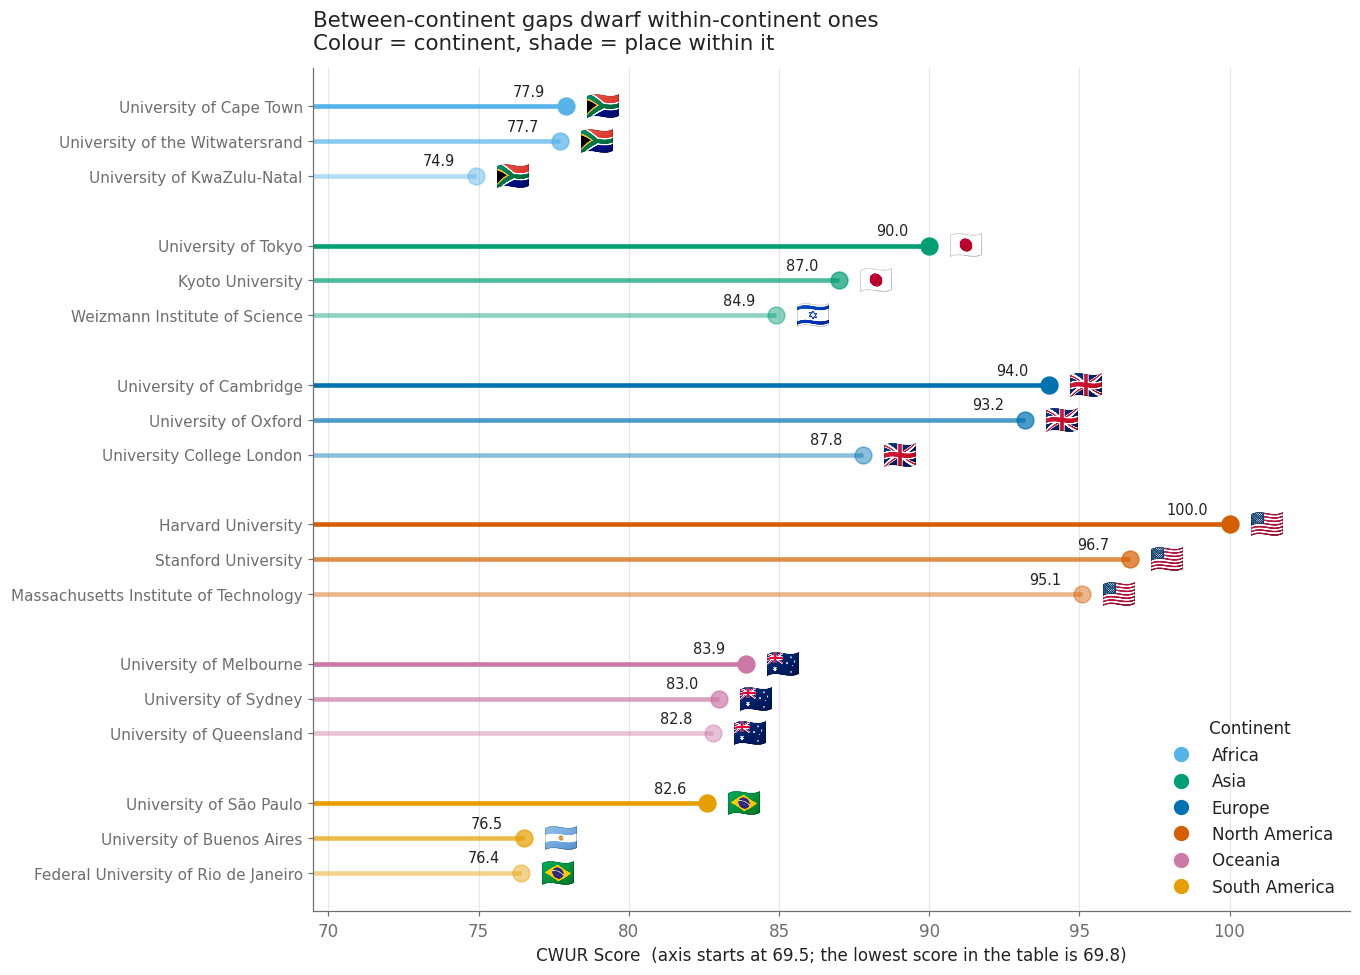

In [18]:
FLAG_CODES = {
    "USA": "us", "United Kingdom": "gb", "Japan": "jp", "Australia": "au",
    "Brazil": "br", "Argentina": "ar", "South Africa": "za", "Israel": "il",
    "Canada": "ca",
}


def flag_image(country):
    """Return a cached flag as a PIL image, or None if unavailable offline."""
    code = FLAG_CODES.get(country)
    if code is None:
        return None
    FLAG_DIR.mkdir(parents=True, exist_ok=True)
    cached = FLAG_DIR / f"{code}.png"
    if not cached.exists():
        try:
            import requests
            response = requests.get(f"https://flagcdn.com/80x60/{code}.png", timeout=10)
            response.raise_for_status()
            cached.write_bytes(response.content)
        except Exception as exc:
            print(f"  no flag for {country} ({type(exc).__name__}) - continuing without it")
            return None
    return Image.open(cached).convert("RGBA")


top3 = (ranked.sort_values("World Rank").groupby("Continent").head(3)
              .sort_values(["Continent", "World Rank"]).copy())
top3["place"] = top3.groupby("Continent")["World Rank"].rank(method="first").astype(int)

# y layout: three bars per continent, a gap between continents
ypos, centres, y = [], {}, 0
for cont in top3["Continent"].unique():
    ypos.extend([y, y + 1, y + 2])
    centres[cont] = y + 1
    y += 4
top3["y"] = ypos

# Score has no meaningful zero (this table runs 69.8-100), so bars from 0 would
# compress every real difference. A dot plot on a stated floor is the honest form.
FLOOR = 69.5

fig, ax = plt.subplots(figsize=(12.5, 9))
for _, row in top3.iterrows():
    base = CONTINENT_COLORS[row["Continent"]]
    alpha = {1: 1.0, 2: 0.7, 3: 0.45}[row["place"]]
    ax.hlines(row["y"], FLOOR, row["Score"], color=base, alpha=alpha, linewidth=3)
    ax.plot(row["Score"], row["y"], "o", markersize=11, color=base, alpha=alpha)
    ax.text(row["Score"] - 0.7, row["y"] - 0.42, f"{row['Score']:.1f}",
            ha="right", va="center", fontsize=9.5, color=C["text"])
    img = flag_image(row["Location"])
    if img is not None:
        ax.add_artist(AnnotationBbox(OffsetImage(img, zoom=0.26),
                                     (row["Score"] + 0.7, row["y"]),
                                     frameon=False, box_alignment=(0, 0.5)))

ax.set_yticks(top3["y"], top3["Institution"], fontsize=10)
ax.set_xlim(FLOOR, 104)
ax.invert_yaxis()
ax.set_xlabel("CWUR Score  (axis starts at 69.5; the lowest score in the table is 69.8)")
ax.set_title("Between-continent gaps dwarf within-continent ones\n"
             "Colour = continent, shade = place within it")
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=9,
                      color=CONTINENT_COLORS[c], label=c)
           for c in top3["Continent"].unique()]
ax.legend(handles=handles, loc="lower right", title="Continent")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06-top3-by-continent.png")
plt.show()


**Takeaway.** The score gap between continents is far larger than within them.
Harvard (100.0) to MIT (95.1) spans five points; Africa's best, the University of
Cape Town, sits at 77.9 — below the *third* institution of every other continent
except South America. Note also that all three African entries and both of South
America's leaders come from a single country each, so "continent" here is close
to a proxy for one national system.


---
## 7. Country-level performance

This is where my first pass went most wrong. It averaged **filled** values over
**all** countries, including ones with a single institution, then read the
leaders off the chart. Two rules fix it: average only *measured* values, and
drop countries below a minimum sample size.


In [19]:
MIN_INSTITUTIONS = 5

sizes = observed["Location"].value_counts()
eligible = sizes[sizes >= MIN_INSTITUTIONS].index

country = (observed[observed["Location"].isin(eligible)]
           .groupby("Location")
           .agg(n=("Institution", "size"),
                mean_world_rank=("World Rank", "mean"),
                **{c: (c, "mean") for c in INDICATORS})
           .sort_values("mean_world_rank"))

print(f"{len(sizes)} countries -> {len(country)} with at least {MIN_INSTITUTIONS} institutions")
print(f"dropped: {', '.join(sorted(set(sizes.index) - set(eligible)))}")
country.head(8).round(1)


61 countries -> 36 with at least 5 institutions
dropped: Argentina, Bulgaria, Chile, Colombia, Croatia, Cyprus, Egypt, Estonia, Iceland, Lebanon, Lithuania, Macau, Mexico, Nigeria, Pakistan, Romania, Saudi Arabia, Serbia, Singapore, Slovak Republic, Slovenia, Thailand, Tunisia, Uganda, Uruguay


,n,mean_world_rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations
Location,,,,,,,,,
Netherlands,13,209.6,308.6,614.7,200.2,222.3,179.7,204.2,188.8
Denmark,5,226.6,510.3,596.5,160.0,237.4,220.6,210.0,181.2
Switzerland,9,256.0,200.6,366.5,80.0,259.6,200.2,136.8,227.7
Israel,7,263.4,183.0,517.8,41.2,349.3,296.7,255.3,464.9
Sweden,12,294.1,302.6,435.6,159.0,312.6,278.9,304.3,289.5
Hong Kong,6,355.5,339.5,320.7,141.0,315.7,279.8,525.4,307.7
Belgium,9,356.4,279.2,524.0,119.5,324.2,354.9,289.6,300.1
Norway,5,358.4,310.0,515.0,70.0,396.0,359.4,341.4,416.2


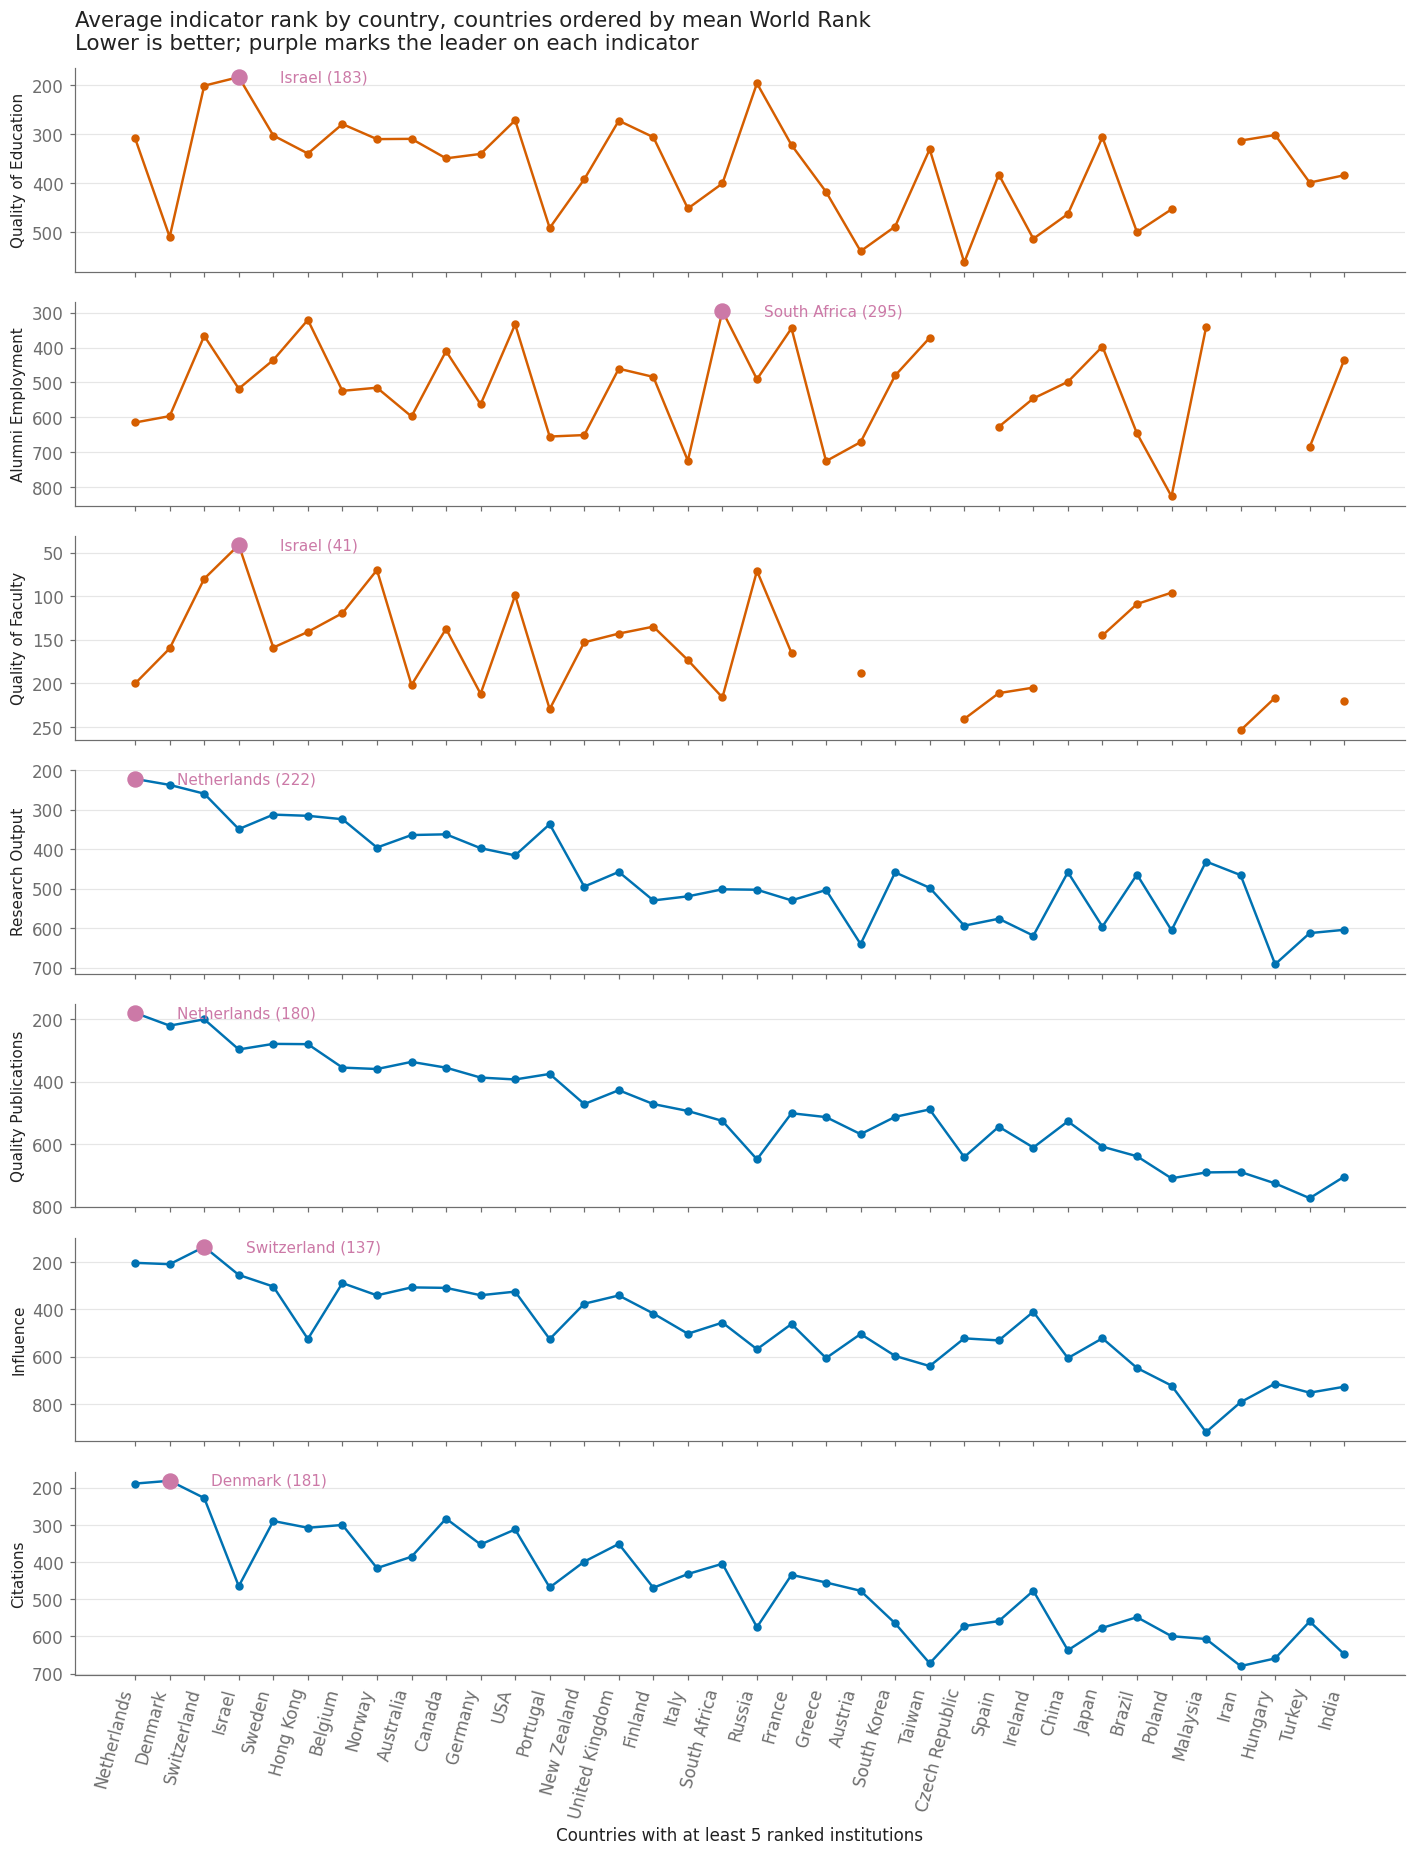

In [20]:
fig, axes = plt.subplots(len(INDICATORS), 1, figsize=(13, 17), sharex=True)
x = np.arange(len(country))

for ax, feature in zip(axes, INDICATORS):
    colour = C["research"] if feature in RESEARCH_BLOCK else C["people"]
    series = country[feature]
    ax.plot(x, series.values, marker="o", markersize=4.5, linewidth=1.6, color=colour)

    best = series.idxmin()
    bx = country.index.get_loc(best)
    ax.scatter([bx], [series.loc[best]], s=95, color=C["accent"], zorder=5)
    ax.annotate(f"{best} ({series.loc[best]:.0f})",
                xy=(bx, series.loc[best]), xytext=(bx + 1.2, series.loc[best]),
                fontsize=10, color=C["accent"], va="center")

    ax.invert_yaxis()          # better rank at the top
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(axis="x", visible=False)

axes[0].set_title("Average indicator rank by country, countries ordered by mean World Rank\n"
                  "Lower is better; purple marks the leader on each indicator")
axes[-1].set_xticks(x, country.index, rotation=75, ha="right")
axes[-1].set_xlabel(f"Countries with at least {MIN_INSTITUTIONS} ranked institutions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07-country-profiles.png")
plt.show()


**Takeaway — and three corrections.** The research panels slope cleanly with mean
World Rank; the people panels are much flatter, consistent with their weaker
correlations in section 5. The `Quality of Faculty` line breaks wherever a whole
country has no measured value — those gaps are the censoring from section 2
showing through, and they are left visible rather than interpolated.

What my first pass got wrong:

| First-pass claim | What the corrected data says |
|---|---|
| "Singapore is the top country on all four research indicators" | Singapore has **2** institutions. Below the threshold; the Netherlands leads on measured values. |
| "Lebanon is best on Alumni Employment" | Lebanon has **1** institution. Dropped. |
| "Switzerland beats all others on Quality of Faculty" | On measured values **Israel** leads (41 vs Switzerland's 80). |

Only the observation about Russia partly survives — it is 2nd on `Quality of
Education` with n=5, which is still thin enough to state with the count attached.
The general lesson is that a country mean over one or two institutions is not a
country mean.


---
## 8. Research strength vs student outcomes

The one part of my first pass I still believe. Two composite indexes, one from
the research indicators and one from the two student-facing ones (`Quality of
Faculty` is excluded — it measures faculty prestige, not what a student gets).

The original divided each rank by its own column maximum, which is wrong: those
maxima are 304, 667 and 1001 depending on the column, so the two indexes were not
on the same scale. Here each rank is divided by **the number of institutions
actually ranked on that indicator**, giving a true "fraction of the ranked field
you are behind" in [0, 1]. Censored institutions score 1.0 — the worst case.

$$\text{Index}_i=\frac{1}{|F|}\sum_{f\in F}\frac{\text{rank}_{i,f}}{n_f+1},
\qquad \text{censored}\rightarrow 1$$


In [21]:
STUDENT_BLOCK = ["Quality of Education", "Alumni Employment"]


def build_index(frame, block, scheme="field"):
    """Mean normalised rank across a block. Lower is better. Censored -> 1.0.

    scheme: 'field'  - divide by the number of institutions ranked on that indicator
            'cutoff' - divide every indicator by the same 1001 cutoff
            'pct'    - percentile rank among measured values
    """
    parts = []
    for c in block:
        col = frame[c]
        if scheme == "field":
            norm = col / (col.notna().sum() + 1)
        elif scheme == "cutoff":
            norm = col / 1001.0
        elif scheme == "pct":
            norm = col.rank(pct=True)
        else:
            raise ValueError(scheme)
        parts.append(norm.fillna(1.0))
    return pd.concat(parts, axis=1).mean(axis=1)


idx = observed.copy()
idx["Research Index"] = build_index(observed, RESEARCH_BLOCK)
idx["Student Index"] = build_index(observed, STUDENT_BLOCK)

top50 = idx.sort_values("World Rank").head(50).reset_index(drop=True)
gap = top50["Student Index"] - top50["Research Index"]
print(f"top 50: mean Research Index {top50['Research Index'].mean():.3f}, "
      f"Student Index {top50['Student Index'].mean():.3f}")
print(f"institutions where the student index is worse: {(gap > 0).sum()}/50")
print(f"mean gap, ranks 1-14: {gap.head(14).mean():+.3f}   ranks 15-50: {gap.iloc[14:].mean():+.3f}")


top 50: mean Research Index 0.041, Student Index 0.307
institutions where the student index is worse: 48/50
mean gap, ranks 1-14: +0.021   ranks 15-50: +0.362


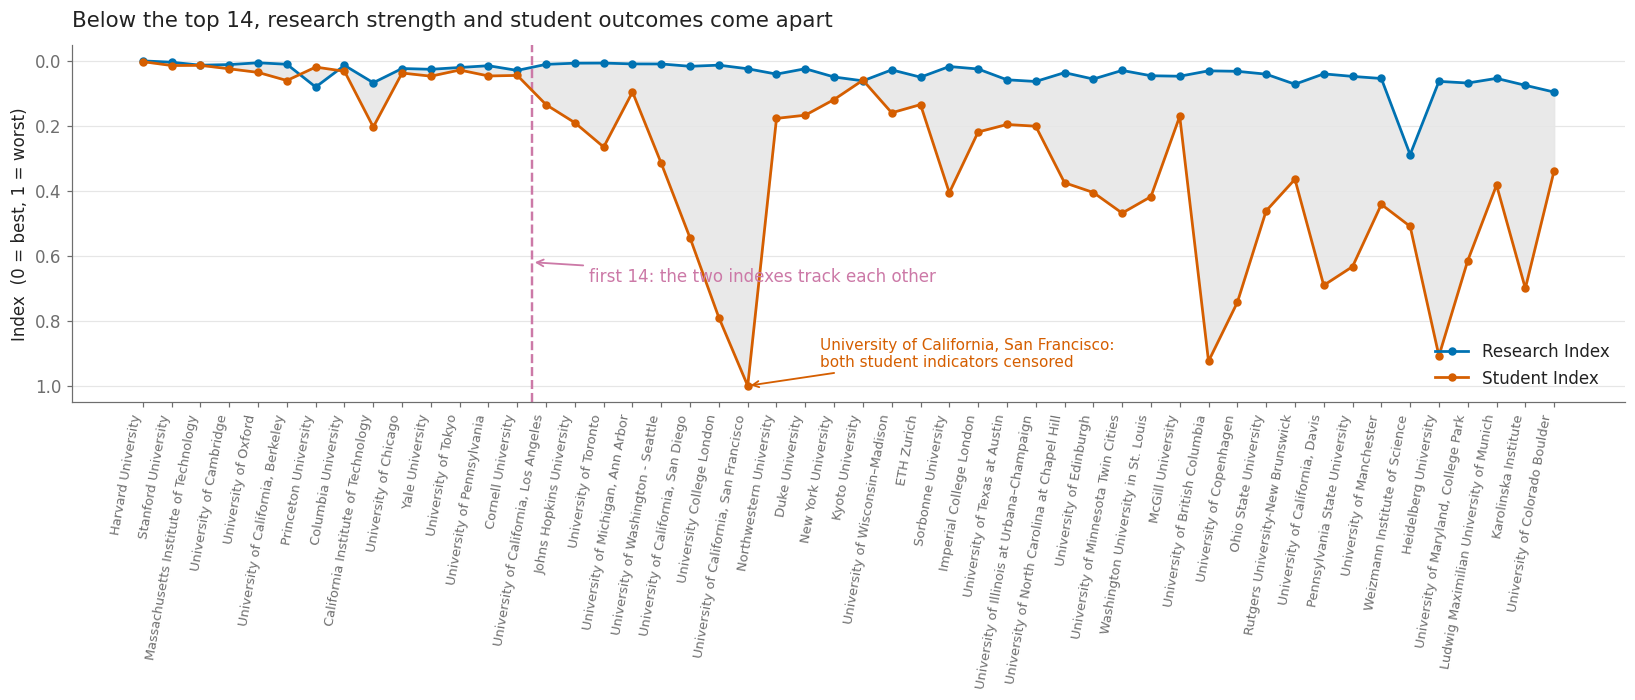

In [22]:
fig, ax = plt.subplots(figsize=(15, 6.5))
x = np.arange(len(top50))

ax.fill_between(x, top50["Research Index"], top50["Student Index"],
                color=C["grid"], alpha=0.85, zorder=1)
ax.plot(x, top50["Research Index"], marker="o", markersize=4.5, linewidth=1.8,
        color=C["research"], label="Research Index", zorder=3)
ax.plot(x, top50["Student Index"], marker="o", markersize=4.5, linewidth=1.8,
        color=C["people"], label="Student Index", zorder=3)

SPLIT = 14
ax.axvline(SPLIT - 0.5, color=C["accent"], linestyle="--", linewidth=1.6, zorder=2)
ax.annotate("first 14: the two indexes track each other",
            xy=(SPLIT - 0.5, 0.62), xytext=(SPLIT + 1.5, 0.68), fontsize=11, color=C["accent"],
            arrowprops=dict(arrowstyle="->", color=C["accent"], linewidth=1.2))

worst = top50["Student Index"].idxmax()
ax.annotate(f"{top50.loc[worst, 'Institution']}:\nboth student indicators censored",
            xy=(worst, top50.loc[worst, "Student Index"]),
            xytext=(worst + 2.5, 0.90), fontsize=10, color=C["people"], va="center",
            arrowprops=dict(arrowstyle="->", color=C["people"], linewidth=1.2))

ax.set_xticks(x, top50["Institution"], rotation=80, ha="right", fontsize=8.5)
ax.set_ylabel("Index  (0 = best, 1 = worst)")
ax.invert_yaxis()
ax.set_title("Below the top 14, research strength and student outcomes come apart")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08-research-vs-student.png")
plt.show()


In [23]:
sensitivity = pd.DataFrame({
    scheme: {
        "Research Index": build_index(observed, RESEARCH_BLOCK, scheme).head(50).mean(),
        "Student Index": build_index(observed, STUDENT_BLOCK, scheme).head(50).mean(),
    }
    for scheme in ("field", "cutoff", "pct")
}).T
sensitivity["gap"] = sensitivity["Student Index"] - sensitivity["Research Index"]
print("Top-50 means under three normalisation schemes:")
sensitivity.round(3)


Top-50 means under three normalisation schemes:


,Research Index,Student Index,gap
field,0.041,0.307,0.266
cutoff,0.037,0.168,0.131
pct,0.042,0.215,0.174


**Takeaway.** Among the top 14 the two indexes are nearly identical (mean gap
+0.02). After that they separate sharply (+0.36): institutions stay world-class
on research while sliding on the student-facing measures. 48 of the top 50 score
worse on the student index than on research.

The gap survives all three normalisation schemes, so it is not an artefact of the
scaling choice — which is what I checked first, because the original version got
that scaling wrong.

**But the honest reading is about the indicators, not the universities.** The
student-facing measures count rare events, so a merely-excellent university has
zero major-award alumni and lands far down that scale, while its paper counts
keep it near the top on research. This chart is at least as much a picture of how
CWUR measures as of what universities are good at — and section 4 showed the
research block drives ~60% of the final score anyway.


---
## 9. Conclusion

**What I found**

1. `World Rank` is `Score` sorted descending — correlating them measures a
   definition, not a relationship.
2. `Score` is reconstructible from the seven indicators at R² = 0.98. The
   research block drives ~60% of it (CI 52–69%), the people block ~40%.
3. The four research indicators correlate 0.72–0.93 with each other, so their
   individual weights are not identifiable — only the block total is.
4. `Score` is rounded to one decimal, giving 195 distinct values for 1,000
   institutions. Sixteen share 69.9 and receive ranks 971–986.
5. Research strength and student outcomes track each other only among the top
   ~14 institutions, then diverge.

**What surprised me.** That the precision problem was invisible until I stopped
plotting distributions and looked at `Score` as a set of values. A 30-place move
in the bottom half of this table can mean nothing at all.

**Limitations**

- 73% of `Quality of Faculty` and 60% of `Quality of Education` are censored;
  everything resting on them is a bound, not an estimate.
- The recovered weights come from 137 uncensored top-200 institutions, which is
  a selected sample — weights may differ further down.
- One edition only, so nothing here says anything about change over time.
- Continent assignment for Russia is a judgement call.

**What I would do next**

- Compare recovered weights against CWUR's published methodology and against the
  2019–20 edition, where the weighting is known to have changed.
- Model `Score` with the censoring handled properly (Tobit or a censored
  likelihood) instead of a floor substitution.
- Bootstrap the rank positions to publish an interval for each university's rank
  rather than a point.

**What changed from my first pass.** The correlation section was rebuilt after I
realised it was measuring a definition; three country claims were withdrawn as
small-sample artefacts; the index normalisation was corrected and then
stress-tested; and the file encoding turned out to explain the "corrupt" names I
had written off.
